In [43]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
)
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

In [44]:
os.environ['KAGGLEHUB_CACHE'] = os.path.abspath('')

# download do dataset via kagglehub
path = kagglehub.dataset_download('blastchar/telco-customer-churn')
csv_path = os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

data = pd.read_csv(csv_path)
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
# Convertendo TotalCharges para numérico
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# verificar valores ausentes
print('Valores ausentes:')
display(data.isna().sum()[data.isna().sum() > 0])

# distribuição da classe-alvo
print('\nDistribuição do Churn:')
display(data['Churn'].value_counts(normalize=True).round(3))

Valores ausentes:


TotalCharges    11
dtype: int64


Distribuição do Churn:


Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

In [46]:
# remover customerID que é só identificador
data = data.drop(columns=['customerID'])

# codificar target: Yes -> 1, No -> 0
data['Churn'] = (data['Churn'] == 'Yes').astype(int)

# definir features e target
TARGET = 'Churn'
NUM_FEATURES = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
CAT_FEATURES = [c for c in data.columns if c != TARGET and c not in NUM_FEATURES]

print(f'Features numéricas ({len(NUM_FEATURES)}): {NUM_FEATURES}')
print(f'Features categóricas ({len(CAT_FEATURES)}): {CAT_FEATURES}')
print(f'Total de features: {len(NUM_FEATURES) + len(CAT_FEATURES)}')

Features numéricas (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Features categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Total de features: 19


In [47]:
x = data.drop(columns=[TARGET])
y = data[[TARGET]]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer([
    ('num', num_transformer, NUM_FEATURES),
    ('cat', cat_transformer, CAT_FEATURES)
])

print(f'Treino: {x_train.shape[0]} amostras | Teste: {x_test.shape[0]} amostras')

Treino: 4930 amostras | Teste: 2113 amostras


In [48]:
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(f_classif)),
    ('xgb', XGBClassifier(random_state=RANDOM_STATE))
])

In [49]:
params_grid_xgb = {
    'selector__k': [2, 5, 10, x_train.shape[1]],
    'xgb__n_estimators': [50, 100, 200, 1000],
    'xgb__learning_rate': np.random.uniform(0.0001, 10, 1000),
    'xgb__class_weight': [None, 'balanced']
}

splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

random_search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=params_grid_xgb,
    scoring='recall_weighted',
    n_iter=100,
    cv=splitter,
    refit=True,
    verbose=10,
    error_score=0,
    random_state=RANDOM_STATE
)

In [50]:
random_search_xgb.fit(x_train, y_train)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
[CV 1/10; 1/100] START selector__k=10, xgb__class_weight=balanced, xgb__learning_rate=5.488881201011971, xgb__n_estimators=200
[CV 1/10; 1/100] END selector__k=10, xgb__class_weight=balanced, xgb__learning_rate=5.488881201011971, xgb__n_estimators=200;, score=0.675 total time=   0.0s
[CV 2/10; 1/100] START selector__k=10, xgb__class_weight=balanced, xgb__learning_rate=5.488881201011971, xgb__n_estimators=200
[CV 2/10; 1/100] END selector__k=10, xgb__class_weight=balanced, xgb__learning_rate=5.488881201011971, xgb__n_estimators=200;, score=0.544 total time=   0.0s
[CV 3/10; 1/100] START selector__k=10, xgb__class_weight=balanced, xgb__learning_rate=5.488881201011971, xgb__n_estimators=200
[CV 3/10; 1/100] END selector__k=10, xgb__class_weight=balanced, xgb__learning_rate=5.488881201011971, xgb__n_estimators=200;, score=0.708 total time=   0.0s
[CV 4/10; 1/100] START selector__k=10, xgb__class_weight=balanced, xgb__learning

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                   error_score=0,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                RobustScaler())]),
                                                                               ['SeniorCitizen',
                                                                                'tenure',
                                                                                'MonthlyCharges',
                                                                                'TotalCharges']),
                                                                              ('cat',
                                                                               OneHotEncoder(drop=...
       5.56910208e+00, 8.16472180e+00, 2.84490641e+00, 7.65978940e+00,
       7.76944831e+00, 2.98260812e+00, 2.39137019e+00, 4.55108244e+00,
       4.24210110e+00, 4.20946597e+00, 2.59953799e-01, 9.38756273e+00,
       6.63041681e+00, 7.36721107e+00, 3.92707583e-01, 5.63875702e+00,
       3.10193289e+00, 8.99623084e+00, 3.61144866e+00, 1.24467319e+00]),
                                        'xgb__n_estimators': [50, 100, 200,
                                                              1000]},
                   random_state=42, scoring='recall_weighted', verbose=10)

In [51]:
random_search_xgb.best_params_

{'xgb__n_estimators': 50,
 'xgb__learning_rate': np.float64(0.5358207975842396),
 'xgb__class_weight': None,
 'selector__k': 19}

In [52]:
yhat_train_xgb = random_search_xgb.best_estimator_.predict(x_train)
yhat_test_xgb = random_search_xgb.best_estimator_.predict(x_test)

# análise das métricas
print('Desempenho - Base de Treino - Random XGBoost')
print(classification_report(y_train, yhat_train_xgb))

# análise do desempenho
print('Desempenho - Base de Teste - Random XGBoost')
print(classification_report(y_test, yhat_test_xgb))

Desempenho - Base de Treino - Random XGBoost
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      3622
           1       0.86      0.77      0.81      1308

    accuracy                           0.91      4930
   macro avg       0.89      0.86      0.87      4930
weighted avg       0.90      0.91      0.90      4930

Desempenho - Base de Teste - Random XGBoost
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1552
           1       0.60      0.50      0.54       561

    accuracy                           0.78      2113
   macro avg       0.72      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113



In [53]:
yhat_test_xgb_proba = random_search_xgb.best_estimator_.predict_proba(x_test)

In [54]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, yhat_test_xgb_proba[:, 1])
auc_xgb = auc(fpr_xgb, tpr_xgb)

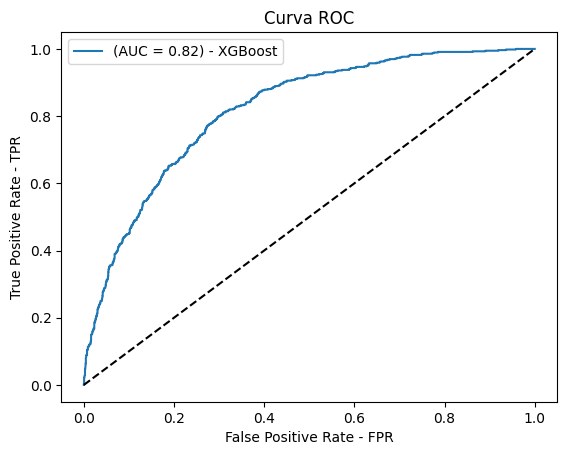

In [55]:
plt.plot(fpr_xgb, tpr_xgb, label=f'(AUC = {auc_xgb:.2f}) - XGBoost')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curva ROC')
plt.xlabel('False Positive Rate - FPR')
plt.ylabel('True Positive Rate - TPR')
plt.legend()
plt.show()

Comparando com o Random Forest o AUC ficou igual mas com uma boa melhoria no f1-score e na precisão.